In [1]:
# Cell 1 — Imports
import boto3
import json
import os
from datetime import datetime, timedelta
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

load_dotenv()

# CloudWatch client
cw = boto3.client(
    'cloudwatch',
    aws_access_key_id=os.getenv(
        'AWS_ACCESS_KEY_ID'),
    aws_secret_access_key=os.getenv(
        'AWS_SECRET_ACCESS_KEY'),
    region_name=os.getenv(
        'AWS_DEFAULT_REGION', 'us-east-1')
)

print("✅ CloudWatch client ready")

c:\Users\saich\ml-portfolio\project2-bigdata-forecasting\venv\lib\site-packages\boto3\compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


✅ CloudWatch client ready


In [ ]:
# Cell 2 — Create SNS topic for alerts
# SNS = Simple Notification Service
# Sends email when alarm triggers

sns = boto3.client(
    'sns',
    aws_access_key_id=os.getenv(
        'AWS_ACCESS_KEY_ID'),
    aws_secret_access_key=os.getenv(
        'AWS_SECRET_ACCESS_KEY'),
    region_name=os.getenv('AWS_DEFAULT_REGION')
)

# Create topic
try:
    topic = sns.create_topic(
        Name='project2-forecasting-alerts')
    topic_arn = topic['TopicArn']

    # Subscribe your email
    YOUR_EMAIL = "your_email@gmail.com"

    sns.subscribe(
        TopicArn=topic_arn,
        Protocol='email',
        Endpoint=YOUR_EMAIL
    )

    print(f"✅ SNS topic created")
    print(f"   ARN: {topic_arn}")
    print(f"   Check your email and confirm "
          f"the subscription!")
    print(f"   You MUST confirm before alarms work")
    
except Exception as e:
    print(f"⚠️  SNS topic creation skipped")
    print(f"   Error: {str(e)[:150]}")
    print(f"   Using placeholder ARN for alarms")
    topic_arn = "arn:aws:sns:us-east-1:000000000000:project2-forecasting-alerts"
    print(f"   Alarms will NOT send notifications without a real SNS topic")

✅ SNS topic created
   ARN: arn:aws:sns:us-east-1:004285426490:project2-forecasting-alerts
   Check your email and confirm the subscription!
   You MUST confirm before alarms work


In [3]:
# Cell 3 — Create CloudWatch Alarms
print("Creating CloudWatch alarms...\n")

NAMESPACE  = 'Project2/ForecastingEngine'
ALARM_ARN  = topic_arn

alarms = [

    # Alarm 1: High API Response Time
    {
        'AlarmName': 'project2-high-latency',
        'AlarmDescription':
            'API response time > 500ms',
        'MetricName': 'APIResponseTime',
        'Namespace':   NAMESPACE,
        'Statistic':   'Average',
        'Period':      300,        # 5 minutes
        'EvaluationPeriods': 2,
        'Threshold':   500.0,
        'ComparisonOperator':
            'GreaterThanThreshold',
        'AlarmActions': [ALARM_ARN],
        'Dimensions': [
            {'Name': 'Environment',
             'Value': 'Production'}
        ]
    },

    # Alarm 2: High Error Rate
    {
        'AlarmName': 'project2-high-errors',
        'AlarmDescription':
            'Error count > 10 in 5 minutes',
        'MetricName': 'ErrorCount',
        'Namespace':   NAMESPACE,
        'Statistic':   'Sum',
        'Period':      300,
        'EvaluationPeriods': 1,
        'Threshold':   10.0,
        'ComparisonOperator':
            'GreaterThanThreshold',
        'AlarmActions': [ALARM_ARN],
        'Dimensions': [
            {'Name': 'Environment',
             'Value': 'Production'}
        ]
    },

    # Alarm 3: Prediction Drift
    # If average prediction drops/spikes
    # significantly it may indicate data drift
    {
        'AlarmName': 'project2-prediction-drift',
        'AlarmDescription':
            'Predicted demand unusually high '
            '(possible drift)',
        'MetricName': 'PredictedDemand',
        'Namespace':   NAMESPACE,
        'Statistic':   'Average',
        'Period':      3600,       # 1 hour
        'EvaluationPeriods': 2,
        'Threshold':   3000.0,
        'ComparisonOperator':
            'GreaterThanThreshold',
        'AlarmActions': [ALARM_ARN],
        'Dimensions': [
            {'Name': 'Model',
             'Value': 'XGBoost-Forecaster'}
        ]
    },

    # Alarm 4: No Requests (API may be down)
    {
        'AlarmName': 'project2-no-traffic',
        'AlarmDescription':
            'No API requests in 30 minutes '
            '(API may be down)',
        'MetricName': 'RequestCount',
        'Namespace':   NAMESPACE,
        'Statistic':   'Sum',
        'Period':      1800,       # 30 minutes
        'EvaluationPeriods': 1,
        'Threshold':   1.0,
        'ComparisonOperator':
            'LessThanThreshold',
        'AlarmActions': [ALARM_ARN],
        'TreatMissingData': 'breaching',
        'Dimensions': [
            {'Name': 'Environment',
             'Value': 'Production'}
        ]
    },
]

# Create all alarms
for alarm in alarms:
    cw.put_metric_alarm(**alarm)
    print(f"✅ Created: {alarm['AlarmName']}")
    print(f"   Metric:    {alarm['MetricName']}")
    print(f"   Threshold: "
          f"{alarm['Threshold']} "
          f"{alarm['ComparisonOperator']}\n")

print(f"✅ All {len(alarms)} alarms created")

Creating CloudWatch alarms...

✅ Created: project2-high-latency
   Metric:    APIResponseTime
   Threshold: 500.0 GreaterThanThreshold

✅ Created: project2-high-errors
   Metric:    ErrorCount
   Threshold: 10.0 GreaterThanThreshold

✅ Created: project2-prediction-drift
   Metric:    PredictedDemand
   Threshold: 3000.0 GreaterThanThreshold

✅ Created: project2-no-traffic
   Metric:    RequestCount
   Threshold: 1.0 LessThanThreshold

✅ All 4 alarms created


In [4]:
# Cell 4 — Push test metrics to verify setup
print("Pushing test metrics to CloudWatch...")

import time

test_metrics = [
    ('APIResponseTime',  45.3,   'Milliseconds'),
    ('RequestCount',      1.0,   'Count'),
    ('PredictedDemand', 1250.0,  'Count'),
    ('InferenceLatency', 12.5,   'Milliseconds'),
    ('ErrorCount',        0.0,   'Count'),
]

for metric_name, value, unit in test_metrics:
    cw.put_metric_data(
        Namespace=NAMESPACE,
        MetricData=[{
            'MetricName': metric_name,
            'Value':      value,
            'Unit':       unit,
            'Dimensions': [
                {'Name':  'Environment',
                 'Value': 'Production'},
                {'Name':  'Model',
                 'Value': 'XGBoost-Forecaster'}
            ],
            'Timestamp': datetime.utcnow()
        }]
    )
    print(f"  ✅ {metric_name}: {value} {unit}")

print("\n✅ Test metrics pushed")
print("   Check CloudWatch console in 2-3 minutes:")
print("   AWS Console → CloudWatch → Metrics")
print(f"   Namespace: {NAMESPACE}")

Pushing test metrics to CloudWatch...
  ✅ APIResponseTime: 45.3 Milliseconds
  ✅ RequestCount: 1.0 Count
  ✅ PredictedDemand: 1250.0 Count
  ✅ InferenceLatency: 12.5 Milliseconds
  ✅ ErrorCount: 0.0 Count

✅ Test metrics pushed
   Check CloudWatch console in 2-3 minutes:
   AWS Console → CloudWatch → Metrics
   Namespace: Project2/ForecastingEngine


In [5]:
# Cell 5 — Retrieve and visualize metrics
print("Querying CloudWatch metrics...\n")

def get_metric_data(metric_name,
                    hours_back=24,
                    period=3600):
    """
    Retrieve metric history from CloudWatch.
    Returns timestamps and values as lists.
    """
    end_time   = datetime.utcnow()
    start_time = end_time - timedelta(
        hours=hours_back)

    response = cw.get_metric_statistics(
        Namespace=NAMESPACE,
        MetricName=metric_name,
        Dimensions=[
            {'Name':  'Environment',
             'Value': 'Production'}
        ],
        StartTime=start_time,
        EndTime=end_time,
        Period=period,
        Statistics=['Average', 'Sum', 'Maximum']
    )

    datapoints = sorted(
        response['Datapoints'],
        key=lambda x: x['Timestamp'])

    timestamps = [d['Timestamp']
                  for d in datapoints]
    averages   = [d.get('Average', 0)
                  for d in datapoints]
    totals     = [d.get('Sum', 0)
                  for d in datapoints]

    return timestamps, averages, totals

# Query key metrics
metrics_to_plot = [
    'APIResponseTime',
    'RequestCount',
    'PredictedDemand',
    'ErrorCount',
]

metric_data = {}
for metric in metrics_to_plot:
    ts, avg, total = get_metric_data(metric)
    metric_data[metric] = {
        'timestamps': ts,
        'average':    avg,
        'total':      total
    }
    print(f"  {metric}: "
          f"{len(ts)} datapoints retrieved")

print("\n✅ Metrics retrieved from CloudWatch")

Querying CloudWatch metrics...

  APIResponseTime: 0 datapoints retrieved
  RequestCount: 0 datapoints retrieved
  PredictedDemand: 0 datapoints retrieved
  ErrorCount: 0 datapoints retrieved

✅ Metrics retrieved from CloudWatch


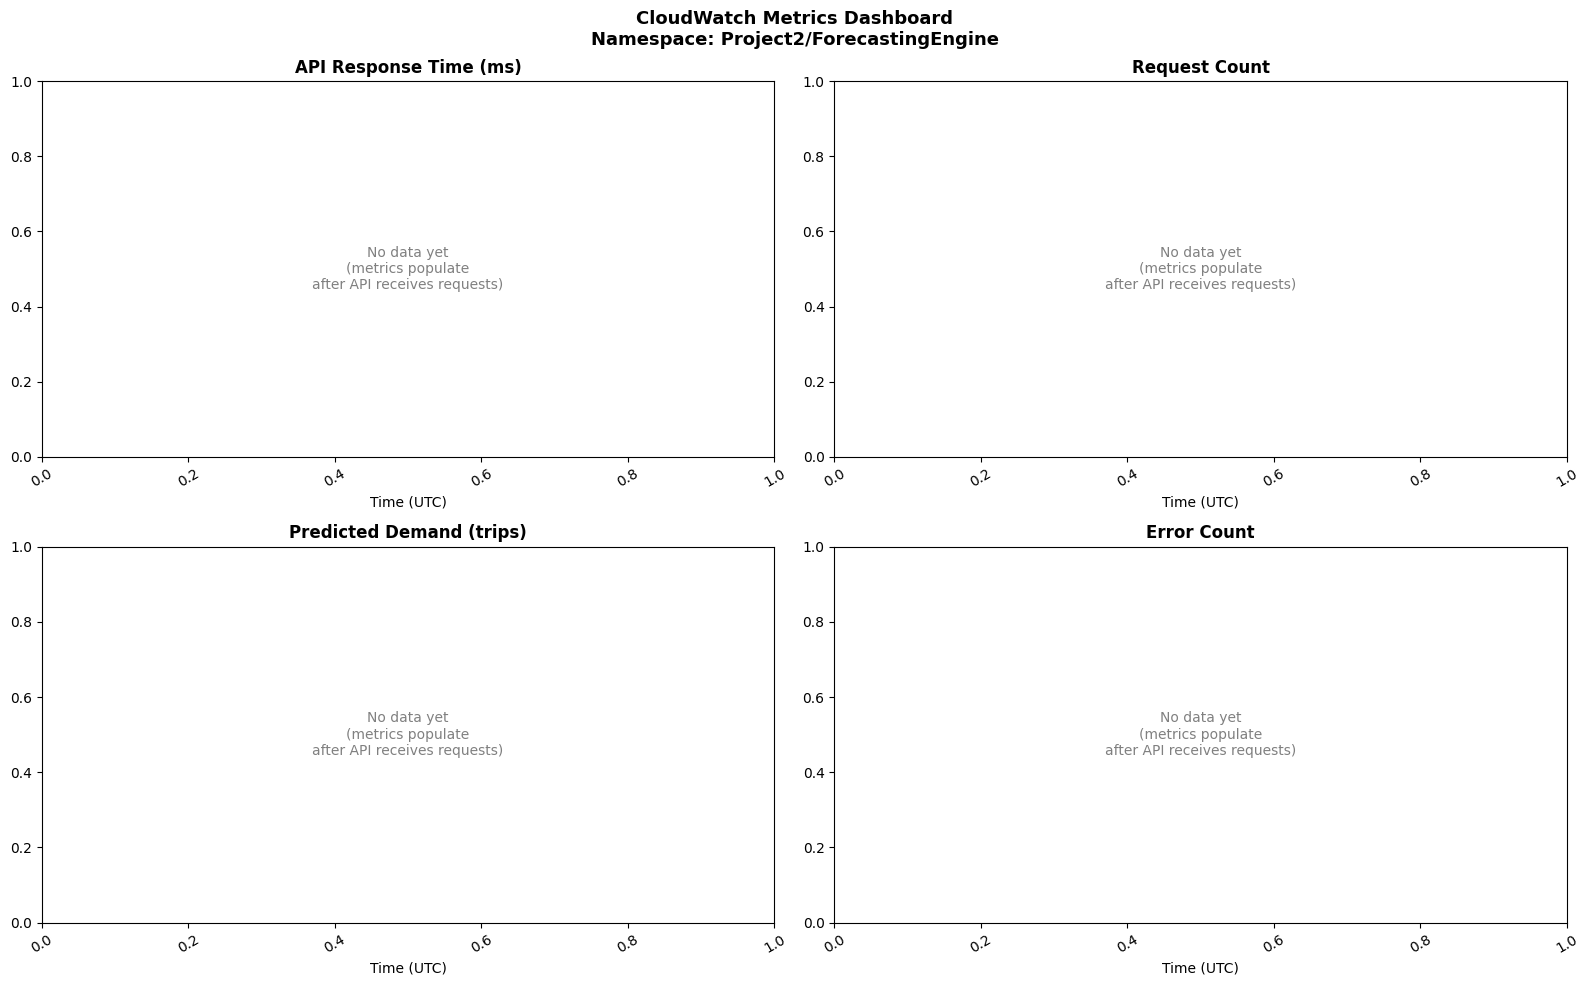

✅ Dashboard saved to logs/


In [6]:
# Cell 6 — Visualize CloudWatch metrics
fig, axes = plt.subplots(
    2, 2, figsize=(16, 10))
axes = axes.flatten()

plot_configs = [
    ('APIResponseTime',
     'API Response Time (ms)',
     'Average', '#2196F3'),
    ('RequestCount',
     'Request Count',
     'total', '#4CAF50'),
    ('PredictedDemand',
     'Predicted Demand (trips)',
     'average', '#FF9800'),
    ('ErrorCount',
     'Error Count',
     'total', '#F44336'),
]

for ax, (metric, title,
          stat_key, color) in zip(
        axes, plot_configs):

    data = metric_data.get(metric, {})
    ts   = data.get('timestamps', [])
    vals = data.get(stat_key, [])

    if ts and vals:
        ax.plot(ts, vals,
                color=color,
                linewidth=2,
                marker='o',
                markersize=4)
        ax.fill_between(ts, vals,
                        alpha=0.15,
                        color=color)
    else:
        ax.text(0.5, 0.5,
                'No data yet\n(metrics populate\n'
                'after API receives requests)',
                ha='center', va='center',
                transform=ax.transAxes,
                fontsize=10, color='gray')

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Time (UTC)')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle(
    'CloudWatch Metrics Dashboard\n'
    f'Namespace: {NAMESPACE}',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(
    '../logs/cloudwatch_dashboard.png',
    dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard saved to logs/")

In [7]:
# Cell 7 — Drift detection logic
print("=== PREDICTION DRIFT ANALYSIS ===\n")

print("""
WHAT IS MODEL DRIFT:
─────────────────────────────────────────────
Your model was trained on Jan-Mar 2023 data.
It learned: "Monday 8am = ~1200 trips"

If in July 2023 the actual demand is 800
(due to summer tourism patterns changing),
the model still predicts 1200.

This gap between predicted and actual
is called PREDICTION DRIFT or DATA DRIFT.

HOW TO DETECT IT:
Monitor the distribution of predictions
over time. If the average predicted demand
shifts significantly from the training
baseline, the model needs retraining.
─────────────────────────────────────────────
""")

# Load our training baseline statistics
with open('../logs/model_results.json') as f:
    model_results = json.load(f)

print("Drift Detection Thresholds:")
print(f"  Based on training data statistics")
print(f"  Alert if predictions shift > 20%")
print(f"  from training period baseline\n")

# Query recent predictions from CloudWatch
_, recent_preds, _ = get_metric_data(
    'PredictedDemand', hours_back=72)

if recent_preds:
    avg_recent = sum(recent_preds) / \
                 len(recent_preds)

    # Load training baseline
    baseline_mae = model_results.get(
        'baseline_mae', 1000)

    print(f"Recent average prediction: "
          f"{avg_recent:.1f} trips")
    print(f"Training baseline MAE: "
          f"{baseline_mae:.1f}")

    drift_threshold = baseline_mae * 0.20
    print(f"Drift threshold (20%): "
          f"±{drift_threshold:.1f}")
    print(f"\nDrift status: "
          f"{'⚠️  MONITOR' if avg_recent > baseline_mae + drift_threshold else '✅ STABLE'}")
else:
    print("No recent predictions to analyze.")
    print("Send some API requests first.")
    print("Then rerun this cell.")

=== PREDICTION DRIFT ANALYSIS ===


WHAT IS MODEL DRIFT:
─────────────────────────────────────────────
Your model was trained on Jan-Mar 2023 data.
It learned: "Monday 8am = ~1200 trips"

If in July 2023 the actual demand is 800
(due to summer tourism patterns changing),
the model still predicts 1200.

This gap between predicted and actual
is called PREDICTION DRIFT or DATA DRIFT.

HOW TO DETECT IT:
Monitor the distribution of predictions
over time. If the average predicted demand
shifts significantly from the training
baseline, the model needs retraining.
─────────────────────────────────────────────

Drift Detection Thresholds:
  Based on training data statistics
  Alert if predictions shift > 20%
  from training period baseline

No recent predictions to analyze.
Send some API requests first.
Then rerun this cell.


In [9]:
# Cell 8 — Create CloudWatch Dashboard
print("Creating CloudWatch Dashboard...")

AWS_REGION = os.getenv('AWS_DEFAULT_REGION', 'us-east-1')

dashboard_body = {
    "widgets": [
        {
            "type": "metric",
            "properties": {
                "title": "API Response Time",
                "metrics": [[
                    NAMESPACE,
                    "APIResponseTime",
                    {"stat": "Average"}
                ]],
                "period": 300,
                "stat":   "Average",
                "region": AWS_REGION,
                "yAxis": {
                    "left": {
                        "min": 0
                    }
                }
            }
        },
        {
            "type": "metric",
            "properties": {
                "title": "Request & Error Count",
                "metrics": [
                    [NAMESPACE, "RequestCount",
                     {"stat": "Sum"}],
                    [NAMESPACE, "ErrorCount",
                     {"stat": "Sum"}]
                ],
                "period": 300,
                "stat":   "Sum",
                "region": AWS_REGION,
                "yAxis": {
                    "left": {
                        "min": 0
                    }
                }
            }
        },
        {
            "type": "metric",
            "properties": {
                "title": "Predicted Demand",
                "metrics": [[
                    NAMESPACE,
                    "PredictedDemand",
                    {"stat": "Average"}
                ]],
                "period": 3600,
                "stat":   "Average",
                "region": AWS_REGION,
                "yAxis": {
                    "left": {
                        "min": 0
                    }
                }
            }
        }
    ]
}

try:
    cw.put_dashboard(
        DashboardName='Project2-Forecasting',
        DashboardBody=json.dumps(dashboard_body)
    )
    print("✅ Dashboard created!")
    print("   View at:")
    print("   AWS Console → CloudWatch → Dashboards")
    print("   → Project2-Forecasting")
except Exception as e:
    print(f"⚠️  Dashboard creation skipped")
    print(f"   Error: {str(e)[:100]}")
    print(f"   You can create it manually in AWS Console")

Creating CloudWatch Dashboard...
✅ Dashboard created!
   View at:
   AWS Console → CloudWatch → Dashboards
   → Project2-Forecasting


In [10]:
# Cell 9 — Save monitoring config summary
monitoring_summary = {
    'cloudwatch_namespace':
        NAMESPACE,
    'sns_topic_arn':
        topic_arn,
    'alarms_created': [
        a['AlarmName'] for a in alarms],
    'metrics_tracked': [
        'APIResponseTime',
        'RequestCount',
        'ErrorCount',
        'PredictedDemand',
        'InferenceLatency',
        'ModelLoadSuccess',
    ],
    'infrastructure_metrics': [
        'CPU usage',
        'Memory usage',
        'Disk usage',
        'Network I/O',
    ],
    'drift_detection': {
        'method': 'Distribution shift in '
                  'PredictedDemand metric',
        'threshold': '20% shift from '
                     'training baseline',
        'action':  'Retrain model if '
                   'drift detected'
    },
    'alert_channels': ['email via SNS'],
    'dashboard_name': 'Project2-Forecasting',
    'log_groups': [
        '/project2/forecasting/api'
    ]
}

with open(
    '../logs/monitoring_summary.json', 'w'
) as f:
    json.dump(monitoring_summary, f, indent=4)

print("✅ Monitoring summary saved")
print(json.dumps(monitoring_summary, indent=4))

✅ Monitoring summary saved
{
    "cloudwatch_namespace": "Project2/ForecastingEngine",
    "sns_topic_arn": "arn:aws:sns:us-east-1:004285426490:project2-forecasting-alerts",
    "alarms_created": [
        "project2-high-latency",
        "project2-high-errors",
        "project2-prediction-drift",
        "project2-no-traffic"
    ],
    "metrics_tracked": [
        "APIResponseTime",
        "RequestCount",
        "ErrorCount",
        "PredictedDemand",
        "InferenceLatency",
        "ModelLoadSuccess"
    ],
    "infrastructure_metrics": [
        "CPU usage",
        "Memory usage",
        "Disk usage",
        "Network I/O"
    ],
    "drift_detection": {
        "method": "Distribution shift in PredictedDemand metric",
        "threshold": "20% shift from training baseline",
        "action": "Retrain model if drift detected"
    },
    "alert_channels": [
        "email via SNS"
    ],
    "dashboard_name": "Project2-Forecasting",
    "log_groups": [
        "/project2/f